In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/kaggle-competition-dl-f-2025/X_test_256.npy
/kaggle/input/kaggle-competition-dl-f-2025/X_train_256.npy
/kaggle/input/kaggle-competition-dl-f-2025/Y_train_256.npy


In [2]:
data_path = "/kaggle/input/kaggle-competition-dl-f-2025"
print(os.listdir(data_path))

['X_test_256.npy', 'X_train_256.npy', 'Y_train_256.npy']


In [3]:
data_path = "/kaggle/input/kaggle-competition-dl-f-2025"

X_train = np.load(os.path.join(data_path, "X_train_256.npy"))
X_test = np.load(os.path.join(data_path, "X_test_256.npy"))
Y_train = np.load(os.path.join(data_path, "Y_train_256.npy"))

In [4]:
print("X_train shape: ", X_train.shape)
print("X_test shape: ", X_test.shape)
print("Y_train shape: ", Y_train.shape)

X_train shape:  (1713, 16, 256, 256)
X_test shape:  (183, 16, 256, 256)
Y_train shape:  (1713, 256, 256)


In [5]:
# Inspect one sample
# Example index
idx =  10

# Get one image and mask
img = X_train[idx]          
mask = Y_train[idx]

print("Image shape: ", img.shape)
print("Mask shape: ", mask.shape)
print("Pixel value range: ", img.min(), "to", img.max())

Image shape:  (16, 256, 256)
Mask shape:  (256, 256)
Pixel value range:  -1.534 to 1.04


<function matplotlib.pyplot.show(close=None, block=None)>

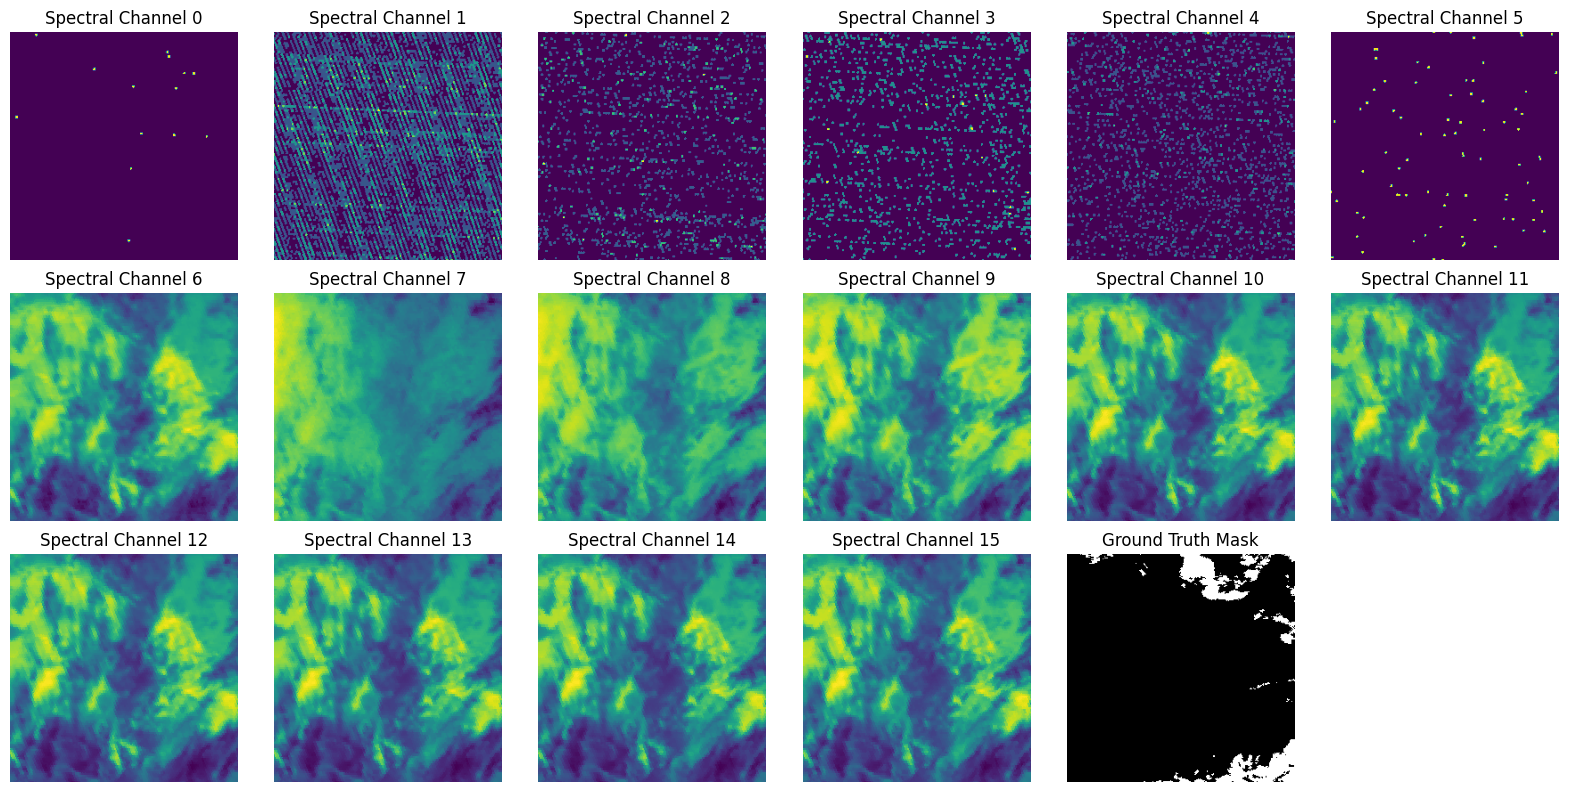

In [6]:
import matplotlib.pyplot as plt

# Visualize some channels
fig, axes = plt.subplots(3,6, figsize = (16, 8))
axes = axes.flatten()
for i, ch in enumerate(range(16)):
    axes[i].imshow(img[ch])
    axes[i].set_title(f"Spectral Channel {ch}")
    axes[i].axis('off')

# Plot corresponding mask
axes[16].imshow(mask, cmap = 'gray')
axes[16].set_title("Ground Truth Mask")
axes[16].axis('off')

for j in range(17, len(axes)):
    axes[j].axis('off')
    
plt.tight_layout()
plt.show

In [7]:
print("Training set size:", len(X_train))
print("Test set size:", len(X_test))
print("Mask unique values:", np.unique(Y_train))

Training set size: 1713
Test set size: 183
Mask unique values: [0 1]


#### Data Preprocessing

In [8]:
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np
import os
import matplotlib.pyplot as plt

In [9]:
# Normalize Image Data
X_train_norm = (X_train + 3) / 6.0
X_test_norm = (X_test + 3) / 6.0

In [10]:
# Convert to PyTorch Tensors
X_train = torch.tensor(X_train, dtype = torch.float32)
Y_train = torch.tensor(Y_train, dtype = torch.float32)
X_test = torch.tensor(X_test, dtype = torch.float32)

# For normalized data
X_train_norm = torch.tensor(X_train_norm, dtype = torch.float32)
X_test_norm = torch.tensor(X_test_norm, dtype = torch.float32)

## Model 
### U-Net Model
Part                                	Function
1. Encoder (Contracting path)           Extracts features and reduces spatial size (via Conv + ReLU + MaxPool).
2. Decoder (Expanding path)         	Upsamples features back to original size, reconstructs spatial details.
3. Skip connections	                    Copy encoder features to the decoder to preserve fine details.

Visually it looks like a big “U” — hence U-Net.

*Model Flow* 
Input (16×H×W)
   ↓
Encoder (Conv blocks + pooling)
   ↓
Bottleneck (deepest layer)
   ↓
Decoder (Upsample + Conv blocks)
   ↓
Output (1×H×W) → segmentation mask (values 0–1)



In [11]:
import torch.nn as nn
import torch.nn.functional as F

In [12]:
# Building Block: Convolution Block
# A smaller helper module: Conv -> BN -> ReLU (twice)

class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(DoubleConv, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size = 3, padding = 1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace = True),
            nn.Conv2d(out_channels, out_channels, kernel_size = 3, padding = 1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace = True)
        )
    def forward(self, x):
        return self.conv(x)

In [13]:
# The U-Net Model
class UNet(nn.Module):
    def __init__(self, in_channels = 16, out_channels = 1):
        super(UNet, self).__init__()

        # Encoder
        self.conv1 = DoubleConv(in_channels, 64)
        self.pool1 = nn.MaxPool2d(2)

        self.conv2 = DoubleConv(64, 128)
        self.pool2 = nn.MaxPool2d(2)

        self.conv3 = DoubleConv(128, 256)
        self.pool3 = nn.MaxPool2d(2)
        
        self.conv4 = DoubleConv(256, 512)
        self.pool4 = nn.MaxPool2d(2)
        
        # Bottleneck
        self.bottleneck = DoubleConv(512, 1024)
        
        # Decoder
        self.upconv4 = nn.ConvTranspose2d(1024, 512, kernel_size = 2, stride = 2)
        self.dec4 = DoubleConv(1024, 512)

        self.upconv3 = nn.ConvTranspose2d(512, 256, kernel_size = 2, stride = 2)
        self.dec3 = DoubleConv(512, 256)

        self.upconv2 = nn.ConvTranspose2d(256, 128, kernel_size = 2, stride = 2)
        self.dec2 = DoubleConv(256, 128)

        self.upconv1 = nn.ConvTranspose2d(128, 64, kernel_size = 2, stride = 2)
        self.dec1 = DoubleConv(128, 64)

        # Output Layer
        self.final_conv = nn.Conv2d(64, out_channels, kernel_size = 1)

    def forward(self, x):
        # Encoder
        c1 = self.conv1(x)
        p1 = self.pool1(c1)
        
        c2 = self.conv2(p1)
        p2 = self.pool2(c2)
        
        c3 = self.conv3(p2)
        p3 = self.pool3(c3)
    
        c4 = self.conv4(p3)
        p4 = self.pool4(c4)
        
        # Bottleneck
        bn = self.bottleneck(p4)
        
        # Decoder
        u4 = self.upconv4(bn)
        u4 = torch.cat([u4, c4], dim = 1)
        c5 = self.dec4(u4)
        
        u3 = self.upconv3(c5)
        u3 = torch.cat([u3, c3], dim = 1)
        c6 = self.dec3(u3)

        u2 = self.upconv2(c6)
        u2 = torch.cat([u2, c2], dim = 1)
        c7 = self.dec2(u2)

        u1 = self.upconv1(c7)
        u1 = torch.cat([u1, c1], dim = 1)
        c8 = self.dec1(u1)

        out = self.final_conv(c8)
        out = torch.sigmoid(out)             # map to 0-1 range for binary segmentation
        return out

In [14]:
print(X_train.shape)
print(X_train_norm.shape)

torch.Size([1713, 16, 256, 256])
torch.Size([1713, 16, 256, 256])


In [15]:
idx = 6
x_sample = X_train[idx].unsqueeze(0)
x_sample_n = X_train_norm[idx].unsqueeze(0)
y_true = Y_train[idx]
model = UNet(in_channels = 16, out_channels = 1)
y_pred = model(x_sample)

print("Input shape: ", x_sample.shape)
print("Output shape: ", y_pred.shape)

Input shape:  torch.Size([1, 16, 256, 256])
Output shape:  torch.Size([1, 1, 256, 256])


In [16]:
model.eval()  # turn off dropout/batchnorm updates
with torch.no_grad():
    y_pred = model(x_sample)  # shape: [1, 1, H, W]
    y_pred_n = model(x_sample_n)

In [17]:
y_pred_prob = torch.sigmoid(y_pred) # [1, 1, H, W], values in [0,1]
y_pred_n_prob = torch.sigmoid(y_pred_n) 

y_pred_mask = (y_pred_prob > 0.5).float()    # binary mask
y_pred_n_mask = (y_pred_n_prob > 0.5).float()   

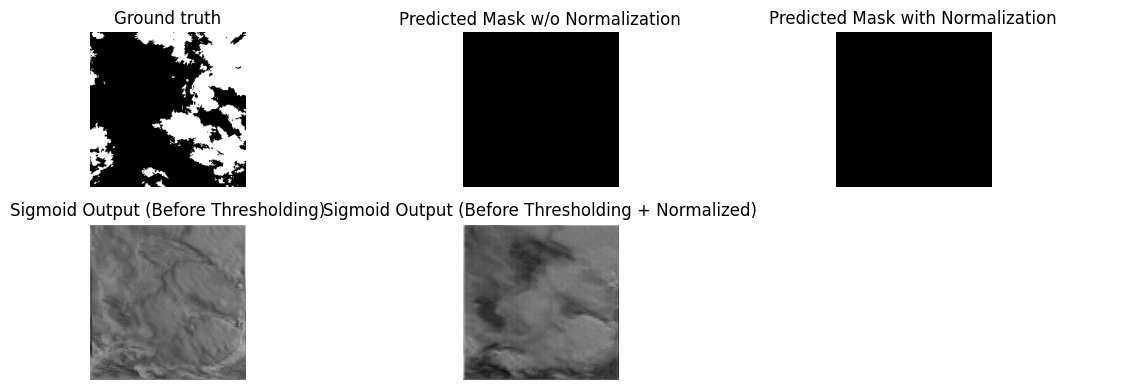

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(12, 4))
axes = axes.flatten()

# Plot
axes[0].imshow(y_true.cpu().squeeze(), cmap='gray')
axes[0].set_title("Ground truth")
axes[0].axis('off')

axes[1].imshow(y_pred_mask.cpu().squeeze(), cmap='gray')
axes[1].set_title("Predicted Mask w/o Normalization")
axes[1].axis('off')

axes[2].imshow(y_pred_n_mask.cpu().squeeze(), cmap='gray')
axes[2].set_title("Predicted Mask with Normalization")
axes[2].axis('off')

axes[3].imshow(y_pred_prob.cpu().squeeze(), cmap='gray')
axes[3].set_title("Sigmoid Output (Before Thresholding)")
axes[3].axis('off')

axes[4].imshow(y_pred_n_prob.cpu().squeeze(), cmap='gray')
axes[4].set_title("Sigmoid Output (Before Thresholding + Normalized)")
axes[4].axis('off')

# Turn off the 6th unused axis
axes[5].axis('off')

plt.tight_layout()
plt.show()


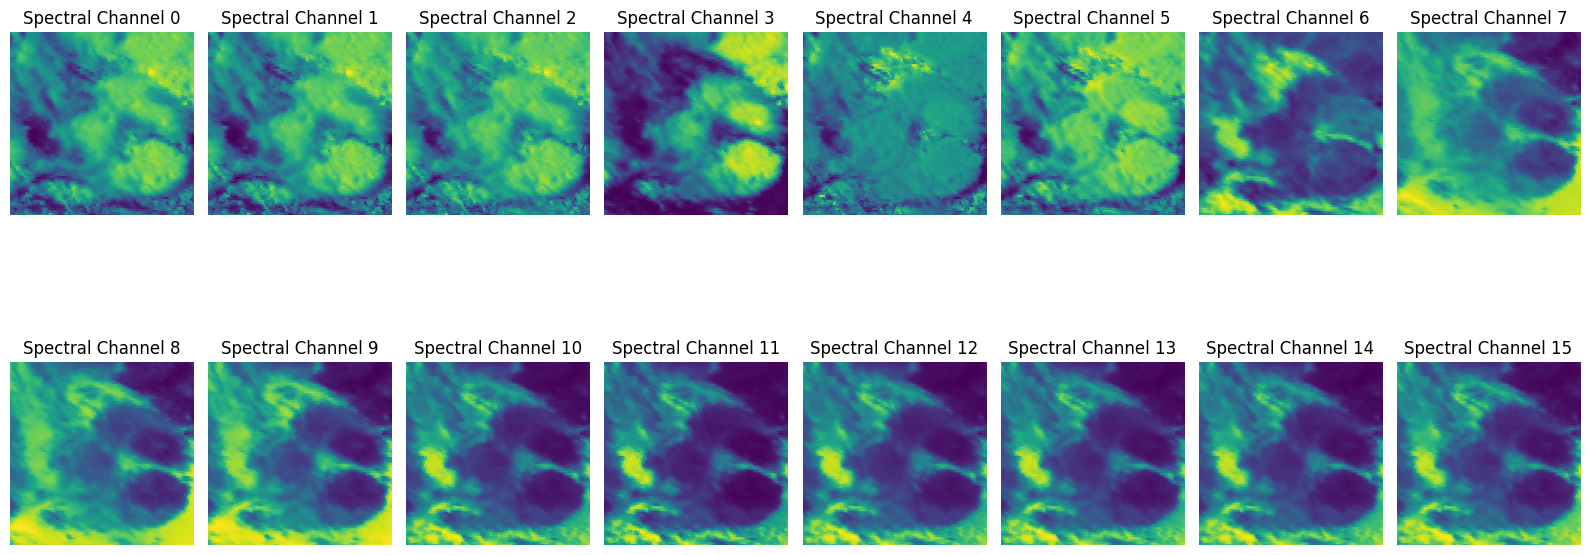

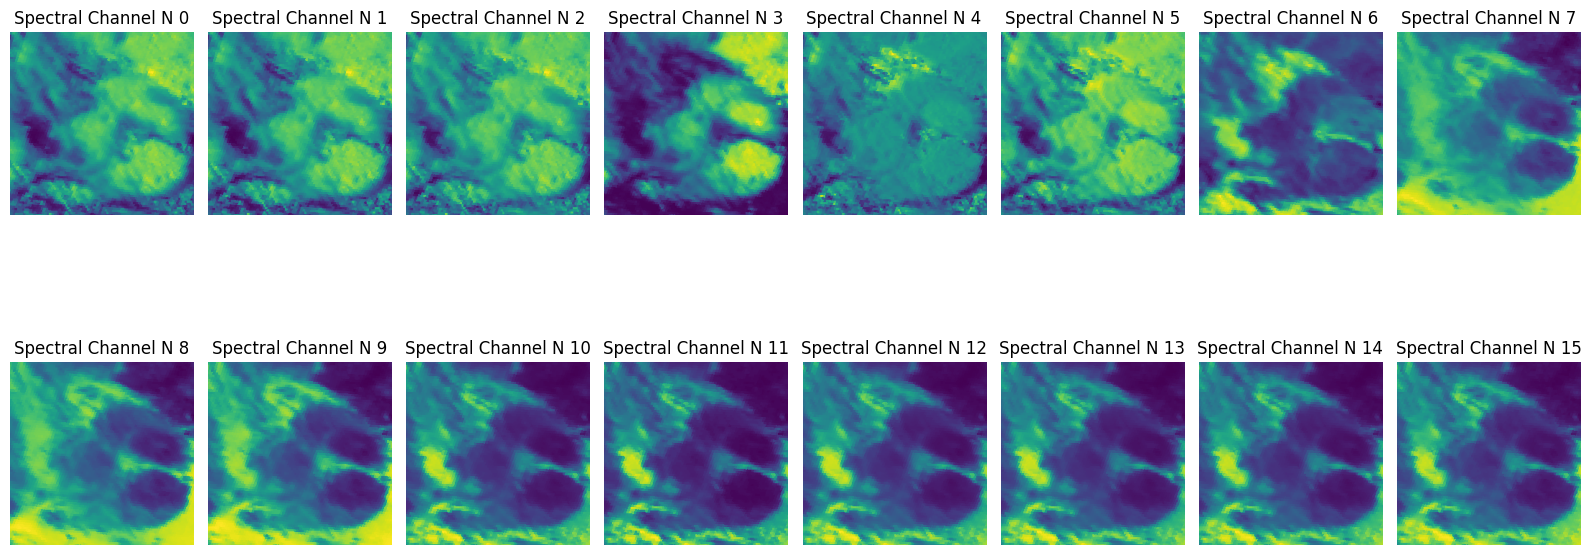

In [19]:
import matplotlib.pyplot as plt

# Visualize some channels
fig, axes = plt.subplots(2,8, figsize = (16, 8))
axes = axes.flatten()
for i in (range(16)):
    axes[i].imshow(x_sample[0, i].cpu().numpy())
    axes[i].set_title(f"Spectral Channel {i}")
    axes[i].axis('off')


plt.tight_layout()
plt.show()

# Visualize some channels
fig, axes = plt.subplots(2,8, figsize = (16, 8))
axes = axes.flatten()
for i, ch in enumerate(range(16)):
    axes[i].imshow(x_sample_n[0, i].cpu().numpy())
    axes[i].set_title(f"Spectral Channel N {ch}")
    axes[i].axis('off')


plt.tight_layout()
plt.show()

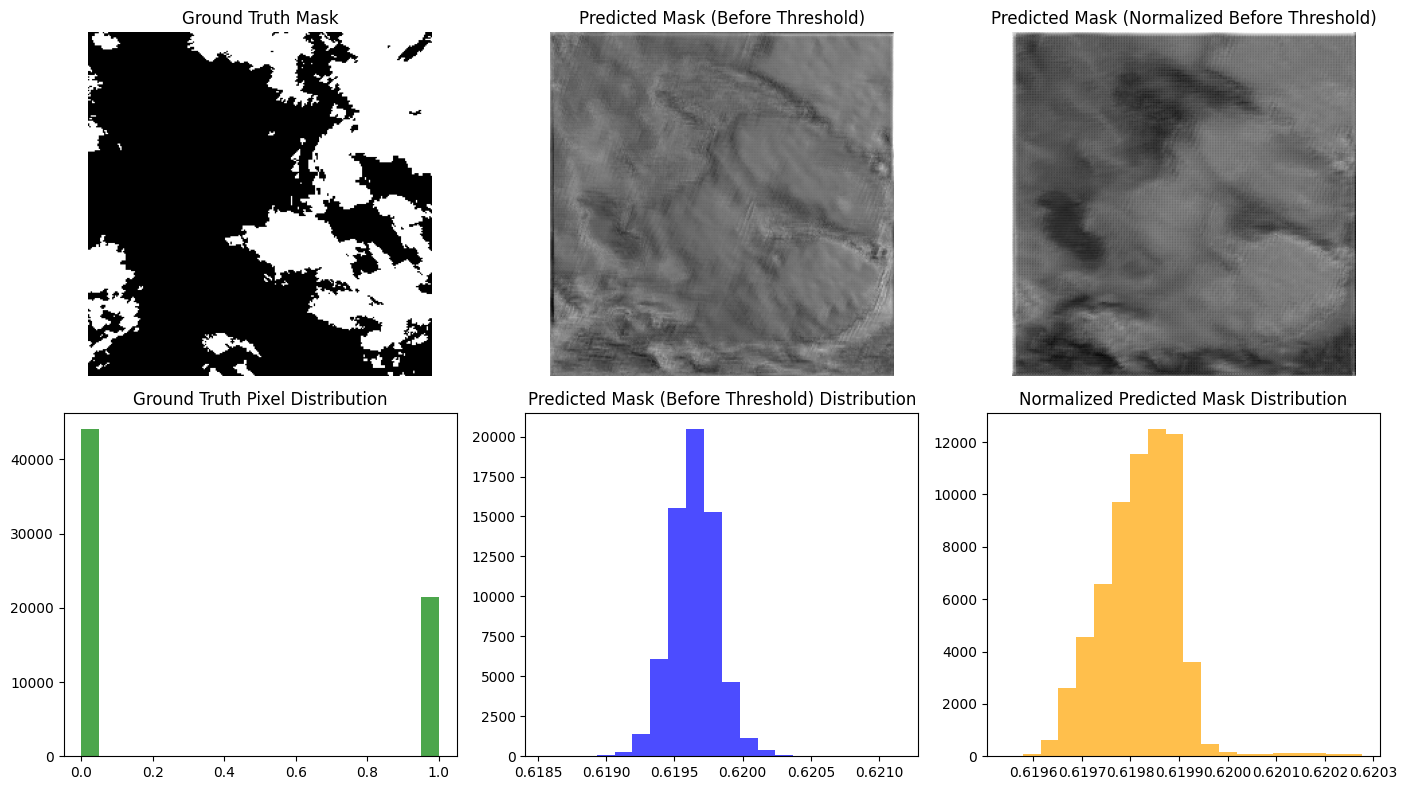

In [20]:
import matplotlib.pyplot as plt
import torch

# Convert everything to CPU NumPy arrays for plotting
y_true_np = y_true.cpu().squeeze().numpy()
y_pred_np = y_pred_prob.cpu().squeeze().numpy()
y_pred_n_np = y_pred_n_prob.cpu().squeeze().numpy()

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

# ----- Row 1: Image comparison -----
axes[0, 0].imshow(y_true_np, cmap='gray')
axes[0, 0].set_title("Ground Truth Mask")
axes[0, 0].axis('off')

axes[0, 1].imshow(y_pred_np, cmap='gray')
axes[0, 1].set_title("Predicted Mask (Before Threshold)")
axes[0, 1].axis('off')

axes[0, 2].imshow(y_pred_n_np, cmap='gray')
axes[0, 2].set_title("Predicted Mask (Normalized Before Threshold)")
axes[0, 2].axis('off')

# ----- Row 2: Histograms -----
axes[1, 0].hist(y_true_np.flatten(), bins=20, color='green', alpha=0.7)
axes[1, 0].set_title("Ground Truth Pixel Distribution")

axes[1, 1].hist(y_pred_np.flatten(), bins=20, color='blue', alpha=0.7)
axes[1, 1].set_title("Predicted Mask (Before Threshold) Distribution")

axes[1, 2].hist(y_pred_n_np.flatten(), bins=20, color='orange', alpha=0.7)
axes[1, 2].set_title("Normalized Predicted Mask Distribution")

plt.tight_layout()
plt.show()

Sigmoid outputs are nearly constant, around 0.625 ± 0.0005, which means:

The model predicts nearly the same probability for every pixel — no structure, no spatial variation.

That’s why when you apply a threshold (say 0.5), every pixel becomes 1.

**Model Not Trained Yet.**

# Model Training

1. Define Loss Function & Optimizer

Since this is a binary segmentation (1 mask channel), we’ll use:

Loss: Binary Cross-Entropy with Logits (BCEWithLogitsLoss)
(It combines sigmoid + BCE in a numerically stable way)

Optimizer: Adam

Learning rate: around 1e-3

In [21]:
import torch
import torch.nn as nn
import torch.optim as optim

# Define loss function
criterion = nn.BCEWithLogitsLoss()

# Define optimizer
optimizer = optim.Adam(model.parameters(), lr=1e-3)

Assuming X_train and Y_train are tensors of shape:

X_train: (N, C, H, W)

Y_train: (N, 1, H, W)

Then:

In [22]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train, Y_train)
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)

train_dataset_n = TensorDataset(X_train_norm, Y_train)
train_loader_n = DataLoader(train_dataset_n, batch_size=8, shuffle=True)


Training Loop:

Send data to the device (CPU/GPU)

Forward pass → compute loss → backpropagate → update weights

In [23]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device: ", device)
model = model.to(device)

num_epochs = 20
train_losses = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        optimizer.zero_grad()
        y_pred = model(X_batch)
        y_batch = y_batch.unsqueeze(1)        # from # from [C, H, W] → [C, 1, H, W]
        loss = criterion(y_pred, y_batch)
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
    
    epoch_loss = running_loss / len(train_loader)
    train_losses.append(epoch_loss)
    print(f"Epoch [{epoch+1}/{num_epochs}] — Loss: {epoch_loss:.4f}")


Using device:  cuda
Epoch [1/20] — Loss: 0.7265
Epoch [2/20] — Loss: 0.6956
Epoch [3/20] — Loss: 0.6940
Epoch [4/20] — Loss: 0.6936
Epoch [5/20] — Loss: 0.6935
Epoch [6/20] — Loss: 0.6933
Epoch [7/20] — Loss: 0.6932
Epoch [8/20] — Loss: 0.6932
Epoch [9/20] — Loss: 0.6932
Epoch [10/20] — Loss: 0.6932
Epoch [11/20] — Loss: 0.6932
Epoch [12/20] — Loss: 0.6932
Epoch [13/20] — Loss: 0.6932
Epoch [14/20] — Loss: 0.6932
Epoch [15/20] — Loss: 0.6932
Epoch [16/20] — Loss: 0.6932
Epoch [17/20] — Loss: 0.6932
Epoch [18/20] — Loss: 0.6932
Epoch [19/20] — Loss: 0.6932
Epoch [20/20] — Loss: 0.6932


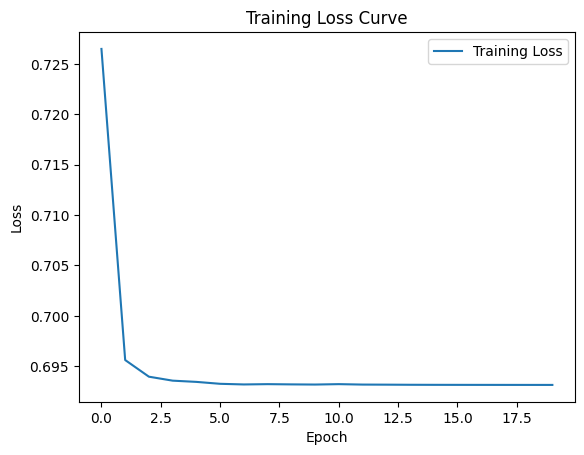

In [24]:
import matplotlib.pyplot as plt

plt.plot(train_losses, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Curve')
plt.legend()
plt.show()
